<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Stochastic-Simulations/blob/master/RandomWalks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Random Walk with absorbing barriers

Consider a sequence of random variables $X_0, X_1, \dots, X_n, \dots$ with values in the set $\mathcal{X} = \{0, 1, \dots, k\}$ defined recursively as follows:

* $X_0 := x_0$ (fixed, deterministic $x_0 \in \mathcal{X}$).
* If $X_n = x$ and $0 < x < k$ then:
  $$X_{n+1} = \begin{cases} x + 1 & \text{with probability } p \\ x - 1 & \text{with probability } 1 - p \end{cases}$$
* If $X_n = x$ and $x \in \{0, k\}$ then $X_{n+1} = x$ with probability $1$.

**Tasks:**
Write a code for simulating $X_0, X_1, \dots, X_n, \dots$. Choose, for example, $k = 20, p = 0.4$.
Compute empirically:
$$\psi_0 = P(X_n = 0 \text{ for some } n \mid X_0 = x_0)$$
$$\psi_k = P(X_n = k \text{ for some } n \mid X_0 = x_0)$$
as functions of $x_0$.

In [24]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
def sample_random_walk_absorbing_barrier(x0=2, min_val=0, max_val=20, p=0.4):
  results = []
  results.append(x0)
  x_current = x0
  x_next = None

  while True:
    if x_current == min_val or x_current == max_val:
      break
    u = np.random.rand()
    if x_current == min_val or x_current == max_val:
      x_next = x_current
    elif u < p:
      x_next = x_current + 1
    else:
      x_next = x_current - 1
    x_current = x_next
    results.append(x_current)


  return results

In [13]:
print(sample_random_walk_absorbing_barrier())
print(sample_random_walk_absorbing_barrier()[-1])

[2, 1, 0]
0


In [23]:
results_20 = {}
N = 10000
for x0 in range(21):
  data = [sample_random_walk_absorbing_barrier(x0=x0) for _ in range(N)]
  last_obs = [data[i][-1] for i in range(N)]
  results_20[x0] = sum(last_obs) / 20 / N # probability of achieving 20 as last

print("Probability of achieving 20 as last element of random walk:")
print(results_20)

results_0 = {}
for x0 in range(21):
  results_0[x0] = 1 - results_20[x0]

print("Probability of achieving 0 as last element of random walk:")
print(results_0)

Probability of achieving 20 as last element of random walk:
{0: 0.0, 1: 0.0001, 2: 0.0003, 3: 0.0007, 4: 0.0011, 5: 0.0017, 6: 0.0036, 7: 0.0049, 8: 0.0081, 9: 0.0092, 10: 0.0169, 11: 0.0269, 12: 0.0374, 13: 0.0565, 14: 0.0881, 15: 0.1241, 16: 0.1969, 17: 0.2951, 18: 0.4467, 19: 0.668, 20: 1.0}
Probability of achieving 0 as last element of random walk:
{0: 1.0, 1: 0.9999, 2: 0.9997, 3: 0.9993, 4: 0.9989, 5: 0.9983, 6: 0.9964, 7: 0.9951, 8: 0.9919, 9: 0.9908, 10: 0.9831, 11: 0.9731, 12: 0.9626, 13: 0.9435, 14: 0.9119, 15: 0.8759, 16: 0.8031, 17: 0.7049000000000001, 18: 0.5533, 19: 0.33199999999999996, 20: 0.0}


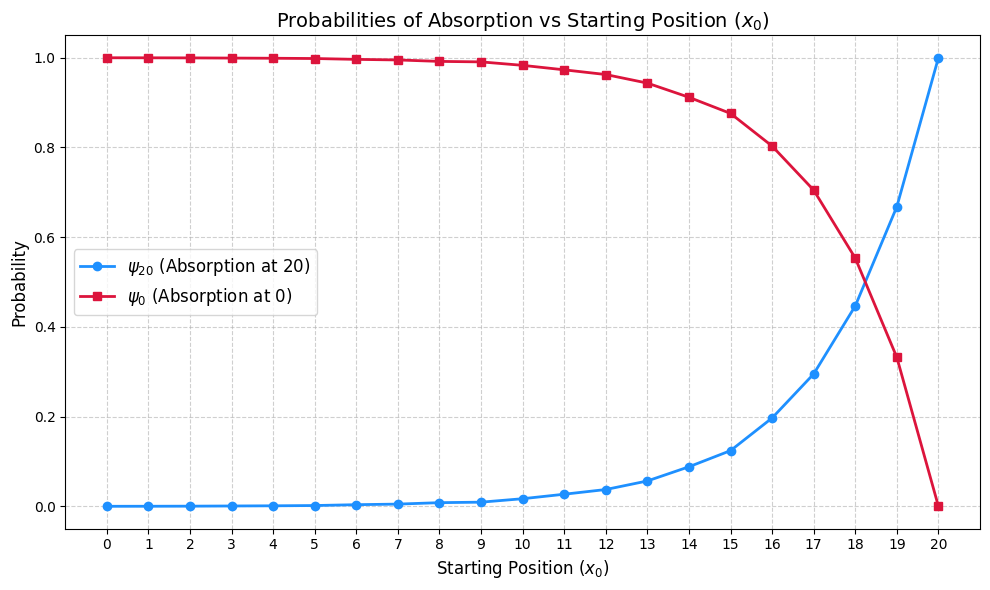

In [25]:
x_vals = list(results_20.keys())
prob_20 = list(results_20.values())
prob_0 = list(results_0.values())

plt.figure(figsize=(10, 6))

plt.plot(x_vals, prob_20, marker='o', linestyle='-', color='dodgerblue', linewidth=2, label=r'$\psi_{20}$ (Absorption at 20)')
plt.plot(x_vals, prob_0, marker='s', linestyle='-', color='crimson', linewidth=2, label=r'$\psi_0$ (Absorption at 0)')

plt.title("Probabilities of Absorption vs Starting Position ($x_0$)", fontsize=14)
plt.xlabel("Starting Position ($x_0$)", fontsize=12)
plt.ylabel("Probability", fontsize=12)

plt.xticks(range(21))
plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

### Random Walk with elastic barriers

Consider a sequence of random variables $X_0, X_1, \dots, X_n, \dots$ with values in the set $\mathcal{X} = \{0, 1, \dots, k\}$ defined recursively as follows:

* $X_0 := x_0$ (fixed, deterministic $x_0 \in \mathcal{X}$).
* If $X_n = x$ then:
  $$X_{n+1} = \begin{cases} \min(x + 1, k) & \text{with probability } p \\ \max(x - 1, 0) & \text{with probability } 1 - p \end{cases}$$

**Tasks:**
Choose, for example, $k = 20, p = 0.4$. Compute empirically:
$$\pi(x) = \lim_{n \to \infty} \frac{1}{n} \sum_{i=1}^n \mathbb{1}(X_i = x)$$
for $x \in \mathcal{X}$.


In [26]:
def sample_random_walk_absorbing_barrier(x0=2, min_val=0, max_val=20, n_steps=10, p=0.4):
  results = []
  results.append(x0)
  x_current = x0
  x_next = None

  for i in range(n_steps):
    u = np.random.rand()
    if u < p:
      x_next = min(x_current + 1, max_val)
    else:
      x_next = max(x_current - 1, min_val)
    x_current = x_next
    results.append(x_current)

  return results

In [28]:
print(sample_random_walk_absorbing_barrier(n_steps=100))

[2, 3, 4, 5, 4, 3, 4, 5, 4, 3, 2, 1, 0, 1, 0, 0, 1, 2, 1, 0, 1, 2, 1, 2, 3, 4, 3, 2, 1, 0, 0, 1, 2, 3, 2, 1, 0, 1, 2, 1, 2, 1, 2, 3, 2, 1, 0, 0, 0, 0, 1, 2, 1, 2, 1, 2, 3, 2, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 2, 1, 2, 3, 4, 3, 2, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 2, 1, 0, 0, 0, 0, 0, 1, 2, 1]


In [30]:
data = sample_random_walk_absorbing_barrier(n_steps=1000000)

In [33]:
count_dict = {}

for x in range(21):
  count_dict[x] = 0

for i in range(len(data)):
  count_dict[data[i]] += 1

for x in range(21):
  count_dict[x] = count_dict[x] / len(data)

In [34]:
print(count_dict)

{0: 0.33380466619533383, 1: 0.22284377715622283, 2: 0.1478908521091479, 3: 0.09848390151609848, 4: 0.0661999338000662, 5: 0.04443795556204444, 6: 0.02954997045002955, 7: 0.01952898047101953, 8: 0.012892987107012893, 9: 0.008552991447008553, 10: 0.005653994346005654, 11: 0.003678996321003679, 12: 0.002320997679002321, 13: 0.001512998487001513, 14: 0.000998999001000999, 15: 0.000632999367000633, 16: 0.000427999572000428, 17: 0.000247999752000248, 18: 0.000153999846000154, 19: 0.000107999892000108, 20: 7.6999923000077e-05}


In [35]:
data = sample_random_walk_absorbing_barrier(x0=14, n_steps=1000000)

In [36]:
count_dict = {}

for x in range(21):
  count_dict[x] = 0

for i in range(len(data)):
  count_dict[data[i]] += 1

for x in range(21):
  count_dict[x] = count_dict[x] / len(data)

In [37]:
print(count_dict)

{0: 0.3324316675683324, 1: 0.2214857785142215, 2: 0.14802485197514803, 3: 0.09936590063409936, 4: 0.06636093363906637, 5: 0.04413295586704413, 6: 0.02950997049002951, 7: 0.019734980265019735, 8: 0.013221986778013221, 9: 0.008934991065008936, 10: 0.005852994147005853, 11: 0.0038749961250038748, 12: 0.002533997466002534, 13: 0.001617998382001618, 14: 0.001072998927001073, 15: 0.000678999321000679, 16: 0.000434999565000435, 17: 0.000298999701000299, 18: 0.000210999789000211, 19: 0.00013599986400013599, 20: 8.2999917000083e-05}


<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\i'
<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\i'
<>:12: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_936/702841167.py:10: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Empirical Stationary Distribution $\pi(x)$ of the Random Walk", fontsize=15)
/tmp/ipykernel_936/702841167.py:11: SyntaxWarning: invalid escape sequence '\i'
  plt.xlabel("State ($x \in \mathcal{X}$)", fontsize=13)
/tmp/ipykernel_936/702841167.py:12: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel("$\pi(x)$", fontsize=13)


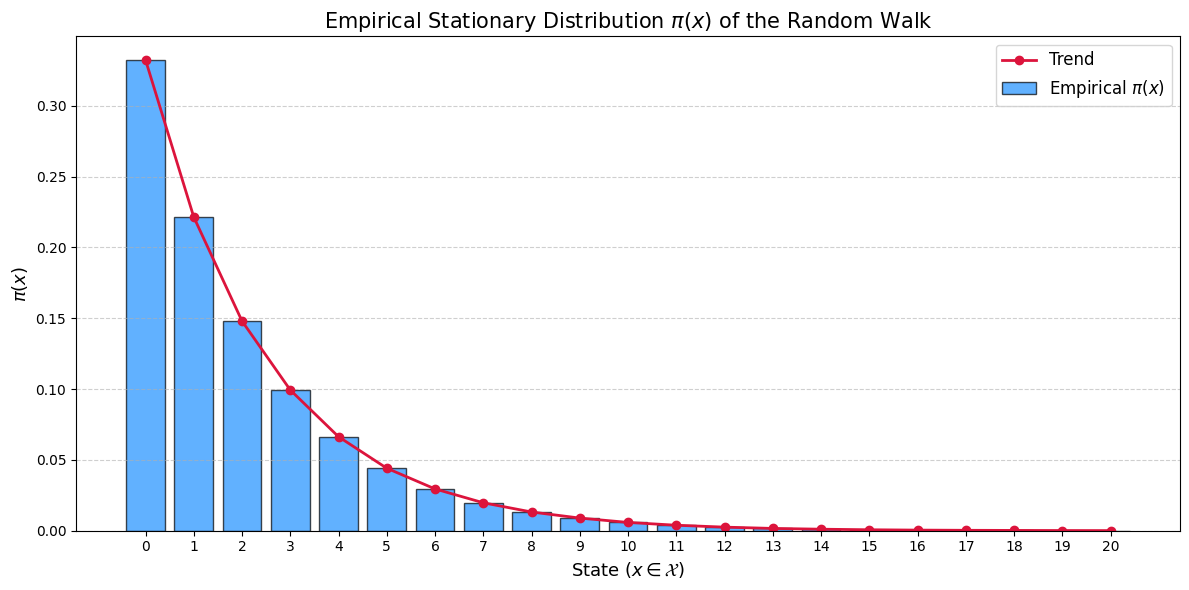

In [44]:
x_vals = list(count_dict.keys())
prob_vals = list(count_dict.values())

plt.figure(figsize=(12, 6))

plt.bar(x_vals, prob_vals, color='dodgerblue', edgecolor='black', alpha=0.7, label=r'Empirical $\pi(x)$')

plt.plot(x_vals, prob_vals, color='crimson', marker='o', linestyle='-', linewidth=2, label='Trend')

plt.title("Empirical Stationary Distribution $\pi(x)$ of the Random Walk", fontsize=15)
plt.xlabel("State ($x \in \mathcal{X}$)", fontsize=13)
plt.ylabel("$\pi(x)$", fontsize=13)

plt.xticks(range(21))

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.legend(fontsize=12)
plt.tight_layout()
plt.show()